# Heart Disease - Exploratory Data Analysis

## Heart Disease (UCI Cleveland, n=303)

This notebook explores the UCI Heart Disease (Cleveland) dataset before any
imputation, outlier clipping, or encoding is applied (that happens in
`src/preprocessing.py`). The raw target `num` (0-4 severity) is binarized to
`target` (0 = no disease, 1 = disease present), which is standard practice
for this dataset in the literature.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import get_disease
from src.preprocessing import DiseasePreprocessor
from src import eda

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


Matplotlib is building the font cache; this may take a moment.


In [2]:
disease = get_disease("heart")
pre = DiseasePreprocessor(disease)
raw_df = pre.load_raw()
df = pre.clean_raw(raw_df)
print(f"Shape after cleaning: {df.shape}")
df.head()

2026-07-30 15:47:49,903 [INFO] [heart] loaded raw data: 303 rows x 14 cols


Shape after cleaning: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 1. Summary Statistics

In [3]:
eda.summary_statistics(df)

,count,mean,std,min,25%,50%,75%,max,missing,dtype
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0,0,int64
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0,0,int64
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0,0,int64
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0,0,int64
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0,0,int64
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0,0,int64
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0,0,int64
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0,0,int64
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0,0,int64
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2,0,float64


## 2. Missing Value Analysis

2026-07-30 15:47:50,257 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/heart_missing_values.png


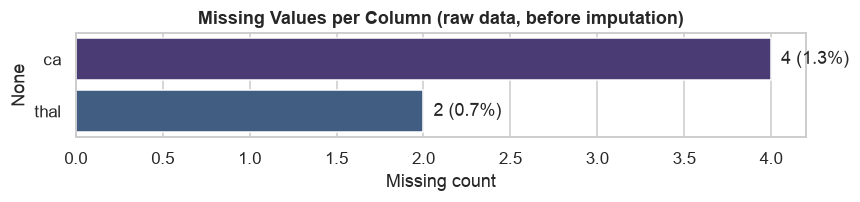

In [4]:
fig = eda.plot_missing_values(df, "heart")
plt.show()

**Interpretation:** Only two columns have missing values: `ca` (number of
major vessels colored by fluoroscopy, 4 missing) and `thal` (thalassemia test
result, 2 missing) - together under 2% of cells. Both are angiographic/nuclear
test results that may simply not have been ordered for every patient. Given
the small amount, median (numeric) / most-frequent (categorical) imputation
in the training pipeline is appropriate; a more complex missing-data model
would be overkill for six missing cells total.


## 3. Disease Prevalence

2026-07-30 15:47:50,324 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/heart_prevalence.png


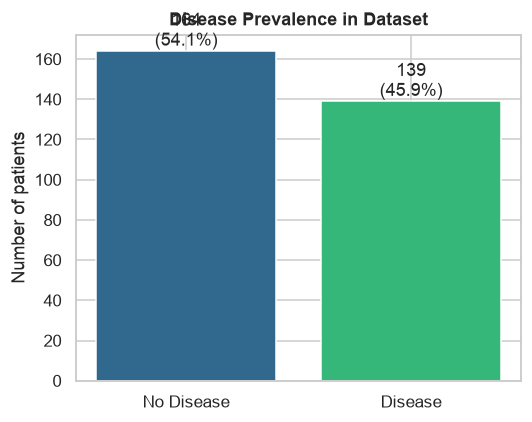

In [5]:
labels = {0: 'No Disease', 1: 'Disease'}
fig = eda.plot_target_prevalence(df, "target", labels, "heart")
plt.show()

**Interpretation:** 45.9% of the 303 patients have heart disease present
(`num > 0`). This is a near-balanced dataset (not a rare-disease scenario),
so accuracy is a reasonably informative metric here, though we still report
ROC-AUC/precision/recall since a false negative (missed diagnosis) and a
false positive (unnecessary follow-up testing) have very different real-world
costs.


## 4. Feature Distributions

2026-07-30 15:47:50,667 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/heart_distributions.png


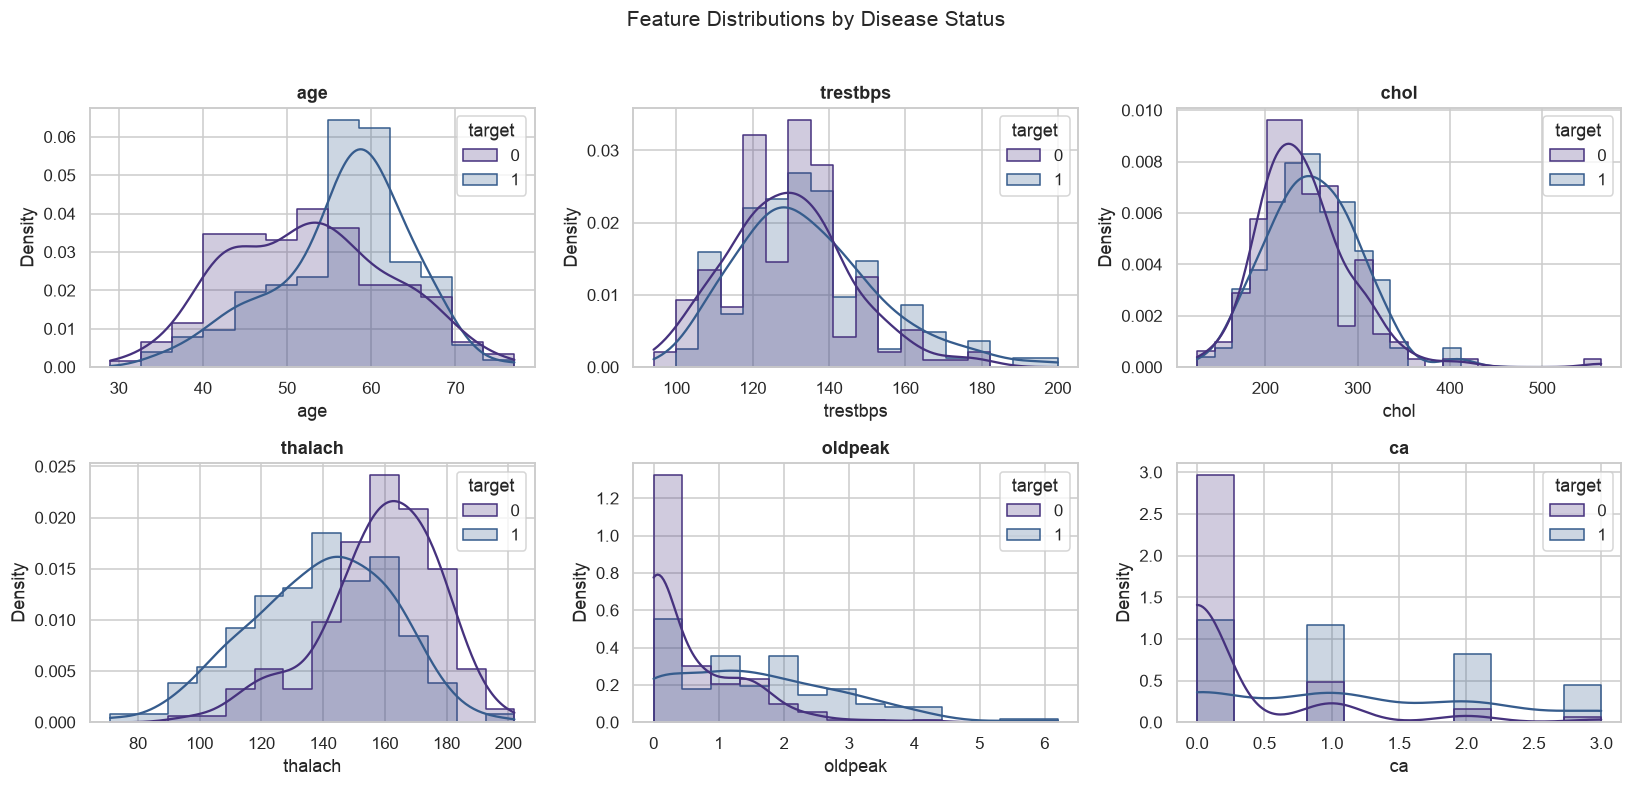

In [6]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
fig = eda.plot_numeric_distributions(df, numeric_cols, "target", "heart")
plt.show()

**Interpretation:** `thalach` (max heart rate achieved) is visibly shifted
lower in the disease-positive group - consistent with reduced exercise
capacity in symptomatic patients. `oldpeak` (ST depression) is right-skewed
and concentrated near 0 for healthy patients but has a heavier right tail for
diseased patients, matching its clinical role as an ischemia indicator.
`chol` and `trestbps` show much weaker separation between groups, foreshadowing
their lower correlation with the target seen in the heatmap below.


## 5. Boxplots (Outlier Visualization)

2026-07-30 15:47:50,841 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:50,843 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:50,852 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:50,855 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:50,864 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-07-30 15:47:50,887 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:50,889 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:50,898 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:50,900 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-30 15:47:51,041 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/heart_boxplots.png


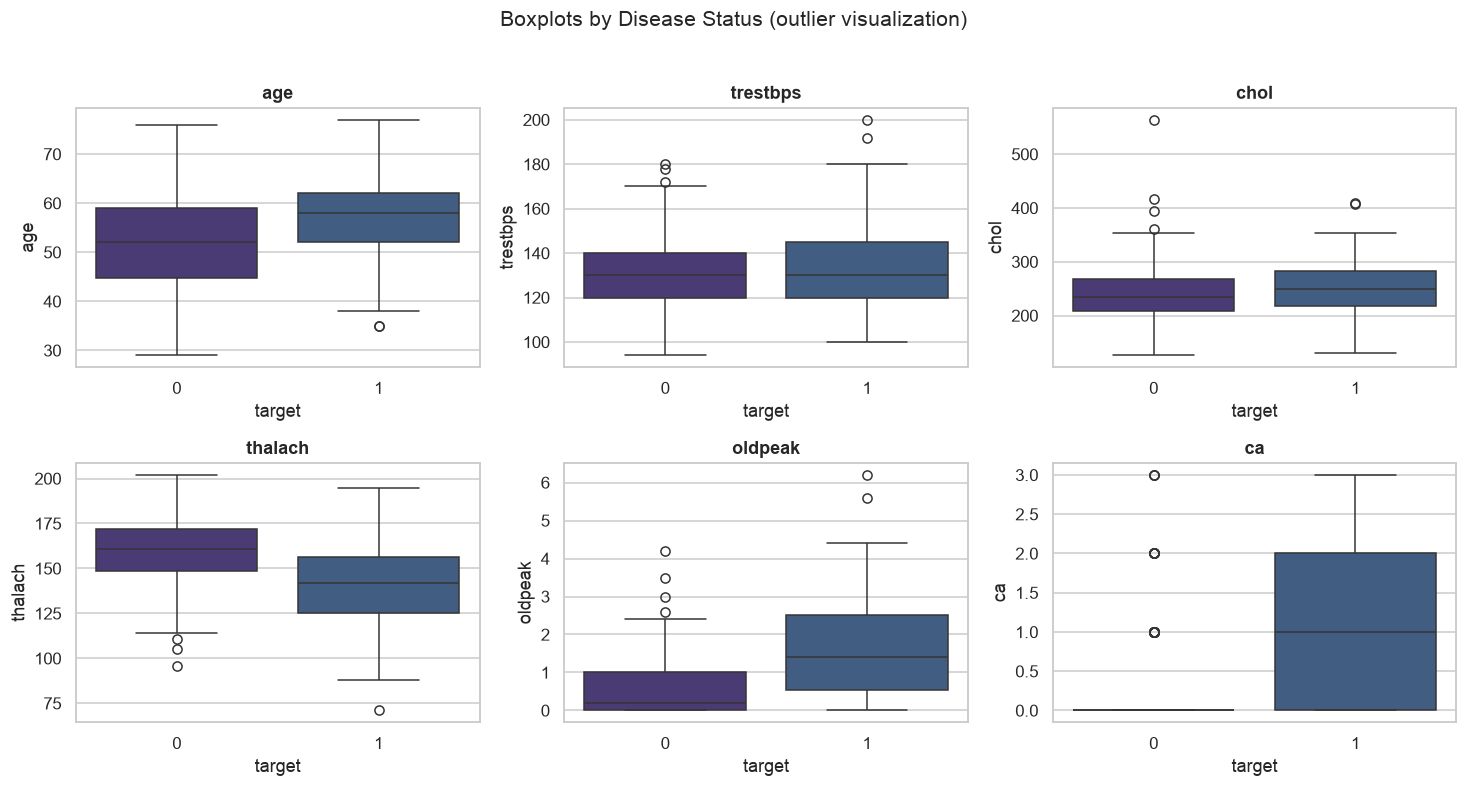

In [7]:
fig = eda.plot_boxplots(df, numeric_cols, "target", "heart")
plt.show()

**Interpretation:** `oldpeak` and `ca` show the clearest median shift and
the most outliers on the high end for the disease-positive group - both are
established markers of ischemic severity, so outliers here likely represent
genuinely severe cases rather than data errors. `chol` has a few very high
outliers (>500 mg/dl) in both groups; these are physiologically plausible
(familial hypercholesterolemia) but are still winsorized in preprocessing so
they don't dominate the small training sample.


## 6. Correlation Matrix

2026-07-30 15:47:51,301 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/heart_correlation_heatmap.png


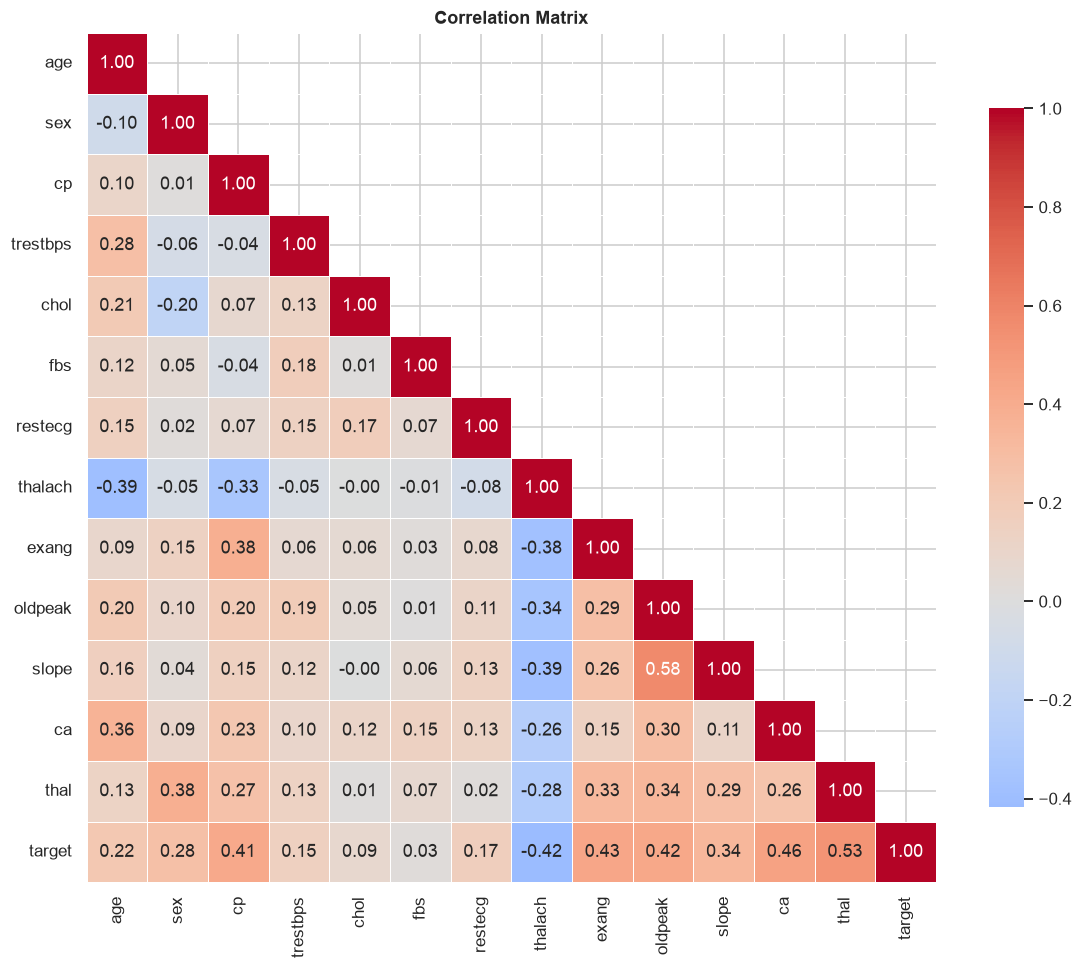

In [8]:
fig = eda.plot_correlation_heatmap(df, "heart")
plt.show()

In [9]:
eda.target_correlation_ranked(df, "target")

thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
thalach    -0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
Name: target, dtype: float64

**Interpretation:** Ranked by |correlation| with `target`: `thal` (0.53),
`ca` (0.46), `exang` (0.43), `oldpeak` (0.42), `thalach` (-0.42), `cp` (0.41).
These six variables - four of which are categorical clinical test results
rather than routine vitals - carry most of the linear signal, which is why a
model that can flexibly combine categorical and continuous features (like
TabPFN) is a good fit rather than one that assumes a fixed functional form.
No pair of *features* is highly collinear (|r| > 0.7), so multicollinearity
is not a concern here.


## 7. Pairplot of Top Correlated Features

2026-07-30 15:47:51,816 [INFO] Saved figure to /Users/albertmathew/Desktop/projects/MultiDiseaseAI/reports/figures/heart_pairplot.png


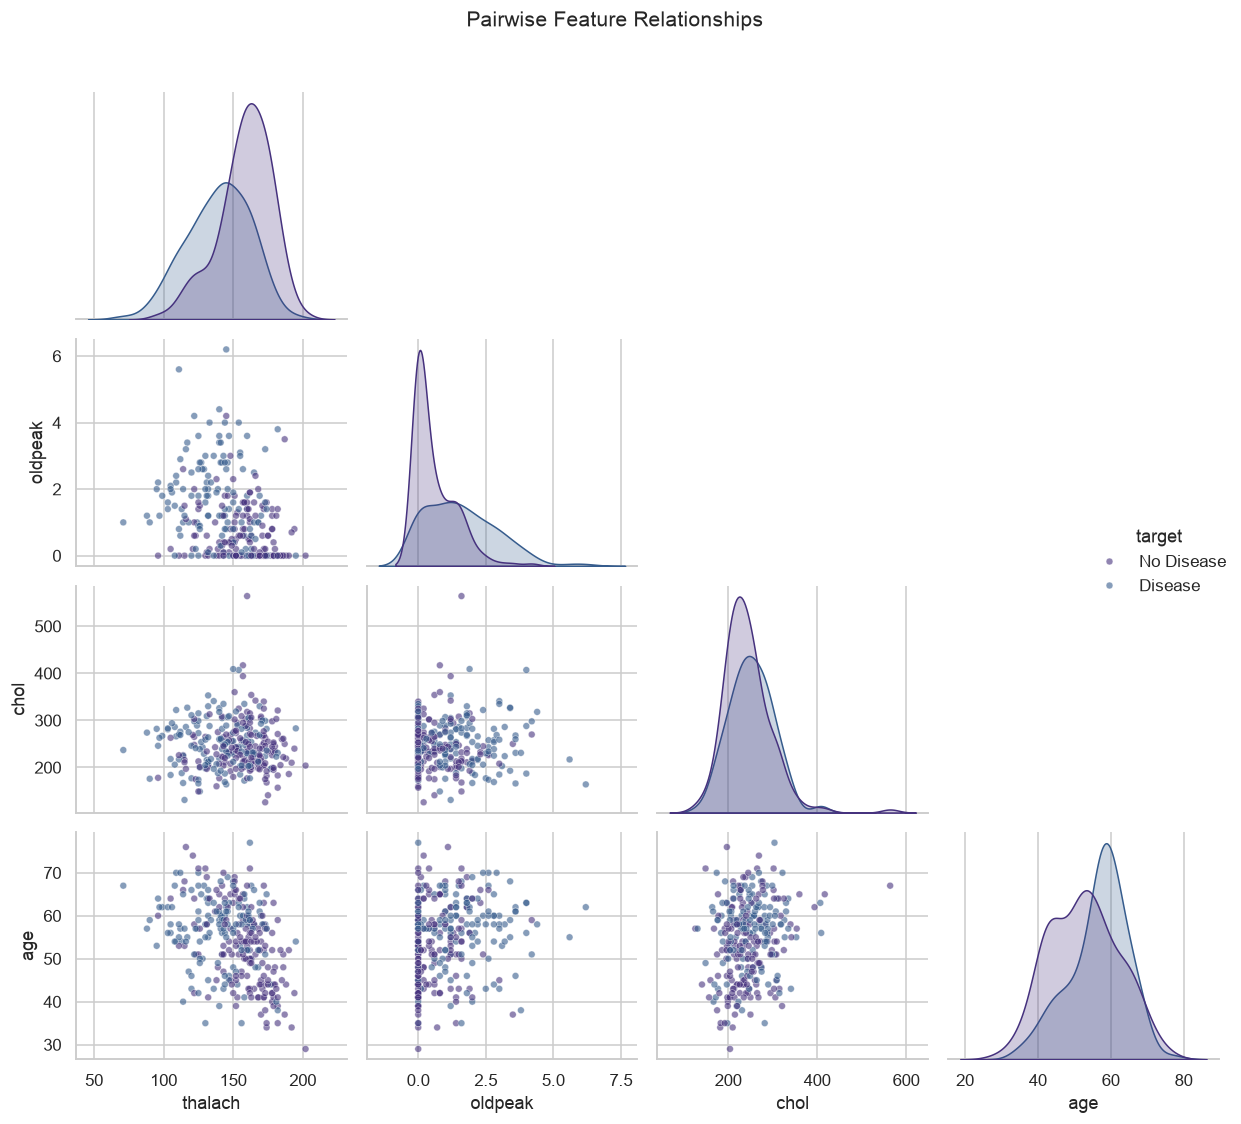

In [10]:
pair_cols = ['thalach', 'oldpeak', 'chol', 'age']
fig = eda.plot_pairplot(df, pair_cols, "target", "heart", labels)
plt.show()

**Interpretation:** `thalach` vs `oldpeak` shows the cleanest visual
separation between the two classes among numeric feature pairs - disease
cases cluster toward low max heart rate and elevated ST depression
simultaneously, suggesting the *combination* of these two features is more
informative than either alone (motivating the `heart_rate_reserve` engineered
feature in `src/feature_engineering.py`, which explicitly combines age,
`thalach`, and the age-predicted maximum).


## 8. Summary of Findings

This EDA directly informs the choices made in `src/preprocessing.py` (imputation strategy, outlier clipping) and `src/feature_engineering.py` (which engineered features to add) for this disease. See `src/train.py` for how the cleaned, engineered features feed into the TabPFN model.